# 🤖 OnePilot — ML Relation Detector v7

## Corrections v7 (par rapport au v6) :
- 🔧 **[v7] MAX_RESULTS supprimé** : toutes les prédictions au-dessus du seuil sont insérées (plus de cap arbitraire à 500)
- 🔧 **[v7] Stratification FK par table** : 20 FK max par table au lieu de toutes sans cap → couverture uniforme de toutes les tables
- 🔧 **[v7] Garde-fou mémoire** : si > 50 000 paires candidates → sous-échantillonnage aléatoire reproductible (seed=42)
- 🔧 **[v7] Poids sample_weight intégrés au dataset** : positifs=1.30, hard_neg=0.70 dès la construction (plus de cellule séparée)
- 🔧 **[v7] Sauvegarde .pkl enrichie** : inclut model_name + trained_at + métriques complètes (compatible ml_detector.py)
- 🔧 **[v7] INSERT ON CONFLICT DO UPDATE** : remplace le delete+insert pour éviter les pertes en cas d'erreur partielle
- ✅ [v6] Profiling features ACTIVÉES (value_overlap, cardinality_ratio, null_rate_compat)
- ✅ [v5] Bug data leakage corrigé
- ✅ [v5] Hard negatives 30%
- ✅ [v5] Seuil auto via PR curve
- ✅ [v5] 16 features, bigrams Jaccard

In [1]:
import subprocess, sys

packages = ["asyncpg", "pandas", "numpy", "scikit-learn", "matplotlib", "xgboost"]

for pkg in packages:
    try:
        __import__(pkg.replace("-", "_").split("[")[0])
        print(f"✅ {pkg}")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"📦 {pkg} installé")

✅ asyncpg
✅ pandas
✅ numpy
📦 scikit-learn installé
✅ matplotlib
✅ xgboost


## 1. 📦 Imports & Config

In [2]:
import asyncpg
import pandas as pd
import numpy as np
import re, pickle, random, warnings
from collections import defaultdict
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
    print(f'   XGBoost {xgb.__version__} disponible ✅')
except ImportError:
    HAS_XGB = False
    print('   XGBoost non disponible — RandomForest + GradientBoosting seulement')

# ── Configuration ──
DB_CONFIG = {
    'host':     'onepilot_postgres',
    'port':     5432,
    'database': 'onepilot_dev',
    'user':     'onepilot',
    'password': 'onepilot_secret'
}

FEATURE_COLS = [
    'name_sim', 'norm_sim', 'entity_in_field', 'type_compat',
    'fk_pattern_a', 'fk_pattern_b', 'pk_fk_pair', 'common_parts',
    'name_contains_entity_a', 'name_contains_entity_b',
    'len_diff', 'prefix_match', 'suffix_match',
    'value_overlap', 'cardinality_ratio', 'null_rate_compat',
]

# ── Paramètres v7 ──
MAX_RESULTS   = None   # None = toutes les prédictions > seuil (plus de cap arbitraire)
FK_PER_TABLE  = 20     # Max colonnes FK candidates par table source
PK_CAP        = 600    # Max colonnes PK candidates en cible
PAIRS_MAX     = 50_000 # Garde-fou mémoire : sous-échantillonnage si > 50k paires

print(f'✅ Config OK — {len(FEATURE_COLS)} features')
print(f'   MAX_RESULTS={MAX_RESULTS} | FK_PER_TABLE={FK_PER_TABLE} | PK_CAP={PK_CAP} | PAIRS_MAX={PAIRS_MAX:,}')

   XGBoost 3.2.0 disponible ✅
✅ Config OK — 16 features
   MAX_RESULTS=None | FK_PER_TABLE=20 | PK_CAP=600 | PAIRS_MAX=50,000


## 2. 🔌 Connexion DB

In [3]:
async def get_conn():
    return await asyncpg.connect(**DB_CONFIG)

conn = await get_conn()
v = await conn.fetchval('SELECT version()')
await conn.close()
print(f'✅ PostgreSQL connecté : {v[:60]}...')

✅ PostgreSQL connecté : PostgreSQL 16.13 on x86_64-pc-linux-musl, compiled by gcc (A...


## 3. 📊 Sélection de la Source

In [4]:
SOURCE_IDX = 0   # ← changer ici pour choisir une autre source

conn = await get_conn()
sources = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type,
           COUNT(DISTINCT se.id)  AS entity_count,
           COUNT(DISTINCT er.id)  AS relation_count
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
        AND er.detection_method != 'ml_predicted'
    GROUP BY ds.id, ds.name, ds.connector_type
    ORDER BY entity_count DESC
""")
await conn.close()

print('📋 Sources disponibles :')
for i, s in enumerate(sources):
    marker = ' ← SÉLECTIONNÉE' if i == SOURCE_IDX else ''
    print(f'  [{i}] {s["name"]} | {s["connector_type"]} | '
          f'{s["entity_count"]} entités | {s["relation_count"]} relations{marker}')

SOURCE_ID   = sources[SOURCE_IDX]['id']
SOURCE_NAME = sources[SOURCE_IDX]['name']
print(f'\n✅ Source sélectionnée : {SOURCE_NAME} ({SOURCE_ID})')

📋 Sources disponibles :
  [0] SXA | mssql | 1264 entités | 3321 relations ← SÉLECTIONNÉE
  [1] adata | odata | 26 entités | 10 relations
  [2] OData Demo Service | odata | 26 entités | 10 relations
  [3] Northwind OData | odata | 26 entités | 14 relations
  [4] northwind | mssql | 12 entités | 12 relations
  [5] test | file_csv | 1 entités | 0 relations
  [6] JSONPlaceholder API | rest | 0 entités | 0 relations

✅ Source sélectionnée : SXA (85a0ef4b-d9af-494f-b24f-ff710c21ba43)


## 3b. 🧹 Nettoyage sources fantômes (optionnel)
*Sources sans entités ni relations — à supprimer si elles polluent la liste.*

In [5]:
conn = await get_conn()
orphans = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
    GROUP BY ds.id, ds.name, ds.connector_type
    HAVING COUNT(DISTINCT se.id) = 0 AND COUNT(DISTINCT er.id) = 0
    ORDER BY ds.name
""")
await conn.close()

if not orphans:
    print('✅ Aucune source fantôme détectée')
else:
    print(f'⚠️  {len(orphans)} source(s) fantôme(s) :')
    for o in orphans:
        print(f'   [{o["id"]}] {o["name"]} ({o["connector_type"]})')
    print('\n→ Pour supprimer, décommenter la cellule suivante et coller les IDs.')

⚠️  1 source(s) fantôme(s) :
   [47c29291-20e0-4852-a5ab-5a6be67b95de] JSONPlaceholder API (rest)

→ Pour supprimer, décommenter la cellule suivante et coller les IDs.


In [6]:
# ⚠️  SUPPRESSION — décommenter et adapter ORPHAN_IDS
# ORPHAN_IDS = ['uuid-1', 'uuid-2']
#
# import uuid as _uuid
# conn = await get_conn()
# async with conn.transaction():
#     for oid in ORPHAN_IDS:
#         uid = _uuid.UUID(oid)
#         await conn.execute('DELETE FROM connection_secrets WHERE source_id=$1', uid)
#         await conn.execute('DELETE FROM entity_relations  WHERE source_id=$1', uid)
#         await conn.execute('DELETE FROM entity_fields WHERE entity_id IN '
#                            '(SELECT id FROM source_entities WHERE source_id=$1)', uid)
#         await conn.execute('DELETE FROM source_entities WHERE source_id=$1', uid)
#         await conn.execute('DELETE FROM entity_profiles  WHERE source_id=$1', uid)
#         r = await conn.execute('DELETE FROM data_sources WHERE id=$1', uid)
#         print(f'🗑️  {oid} supprimée : {r}')
# await conn.close()
# print('✅ Nettoyage terminé')

print('ℹ️  Bloc désactivé — décommenter pour supprimer')

ℹ️  Bloc désactivé — décommenter pour supprimer


## 4. 📥 Chargement des données

In [7]:
conn = await get_conn()

fields_rows = await conn.fetch("""
    SELECT se.id AS entity_id, se.name AS entity_name,
           ef.name AS field_name, ef.data_type,
           ef.is_primary_key, ef.is_foreign_key, ef.position
    FROM source_entities se
    JOIN entity_fields ef ON ef.entity_id = se.id
    WHERE se.source_id = $1
    ORDER BY se.name, ef.position
""", SOURCE_ID)

relations_rows = await conn.fetch("""
    SELECT source_entity, source_field, target_entity, target_field,
           detection_method, confidence,
           CASE
               WHEN detection_method = 'explicit_fk'  THEN 1.0
               WHEN detection_method = 'view_join'    THEN 1.0
               WHEN detection_method LIKE '%name_pascal%' THEN 0.8
               WHEN detection_method LIKE '%name_m2m%'    THEN 0.7
               WHEN detection_method LIKE '%fuzzy%'       THEN 0.5
               WHEN is_confirmed = TRUE                   THEN 0.9
               ELSE 0.6
           END AS sample_weight
    FROM entity_relations
    WHERE source_id = $1
      AND detection_method != 'ml_predicted'
      AND (is_confirmed IS NULL OR is_confirmed = TRUE)
    ORDER BY sample_weight DESC
""", SOURCE_ID)

await conn.close()

df_fields    = pd.DataFrame([dict(r) for r in fields_rows])
df_relations = pd.DataFrame([dict(r) for r in relations_rows])

print(f'✅ Champs chargés   : {len(df_fields):,}')
print(f'   Entités          : {df_fields["entity_name"].nunique():,}')
print(f'✅ Relations (pos)  : {len(df_relations):,}')
print(f'   Méthodes         : {df_relations["detection_method"].value_counts().to_dict()}')
print(f'   Poids moyens     : {df_relations["sample_weight"].mean():.3f}')

if len(df_relations) < 10:
    print('\n⚠️  Moins de 10 relations — lance ↻ Relancer dans l\'UI pour détecter les relations d\'abord.')

✅ Champs chargés   : 12,219
   Entités          : 1,264
✅ Relations (pos)  : 2,484
   Méthodes         : {'explicit_fk': 2483, 'heuristic_name_pascal': 1}
   Poids moyens     : 1.000


## 4b. 📊 Chargement des profils (entity_profiles)
*Active les 3 features profiling : value_overlap, cardinality_ratio, null_rate_compat.*

In [8]:
import json as _json

conn = await get_conn()
profile_rows = await conn.fetch("""
    SELECT entity_name, profile_data
    FROM entity_profiles
    WHERE source_id = $1
      AND profile_data->>'error' IS NULL
      AND (profile_data->>'total_rows')::int > 0
""", SOURCE_ID)
await conn.close()

profile_index = {}
for row in profile_rows:
    table = row['entity_name'].upper()
    data  = row['profile_data']
    if isinstance(data, str):
        data = _json.loads(data)
    for col in data.get('columns', []):
        key = (table, col['name'].upper())
        profile_index[key] = {
            'unique_count': col.get('unique_count', 0),
            'null_rate':    col.get('null_rate', 0.5),
            'top_values':   set(str(v['value']) for v in col.get('top_values', [])),
        }

tables_profiled = len(set(k[0] for k in profile_index))
print(f'✅ Profils chargés  : {len(profile_index):,} champs indexés')
print(f'   Tables profilées : {tables_profiled}')
if tables_profiled == 0:
    print('   ⚠️  Aucun profil → value_overlap=0.0 (valeurs neutres — résultats moins précis)')
    print('   💡 Pour profiler : POST /sources/{id}/profile/all depuis l\'API')

✅ Profils chargés  : 5,197 champs indexés
   Tables profilées : 466


## 5. 🔧 Feature Engineering (16 features)
- 13 features noms/types (Jaccard bigrams)
- 3 features profiling (value_overlap, cardinality_ratio, null_rate_compat)

In [9]:
FK_PATTERNS = ['_id','_fk','id_','fk_','_code','_num','_no','_key','_ref']
TYPE_GROUPS = {
    'int':  ['int','integer','bigint','smallint','tinyint','numeric','decimal','number'],
    'str':  ['varchar','nvarchar','char','nchar','text','ntext','string'],
    'date': ['date','datetime','datetime2','timestamp'],
}

def normalize(name):
    n = name.lower()
    for p in ['fk_','pk_','id_','num_','cod_','f_','c_']:
        if n.startswith(p): n = n[len(p):]; break
    for s in ['_id','_fk','_pk','_key','_code','_num','_no','_ref']:
        if n.endswith(s): n = n[:-len(s)]; break
    return n

def type_group(dtype):
    d = dtype.lower()
    return next((g for g, ts in TYPE_GROUPS.items() if any(t in d for t in ts)), 'other')

def fk_pat(name):
    n = name.lower()
    return float(any(n.startswith(p) or n.endswith(p) for p in FK_PATTERNS))

def sim(a, b):
    """Similarité Jaccard sur bigrams — O(n), 50× plus rapide que SequenceMatcher."""
    a, b = a.lower(), b.lower()
    if a == b: return 1.0
    if not a or not b: return 0.0
    sa = set(a[i:i+2] for i in range(len(a)-1))
    sb = set(b[i:i+2] for i in range(len(b)-1))
    if not sa and not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def camel_parts(name):
    return set(p.lower() for p in re.sub(r'([A-Z])', r' \1', name).split() if len(p) > 1)

def compute_features(ea, fa, dta, is_pk_a, is_fk_a,
                      eb, fb, dtb, is_pk_b, is_fk_b):
    na, nb     = normalize(fa), normalize(fb)
    ea_n, eb_n = normalize(ea), normalize(eb)
    parts_a    = camel_parts(fa)
    parts_b    = camel_parts(fb)
    common     = len(parts_a & parts_b) / max(len(parts_a | parts_b), 1)

    # ── 3 profiling features (neutres si profil absent) ──
    pa = profile_index.get((ea.upper(), fa.upper()), {})
    pb = profile_index.get((eb.upper(), fb.upper()), {})

    top_a, top_b = pa.get('top_values', set()), pb.get('top_values', set())
    if top_a and top_b:
        u = len(top_a | top_b)
        value_overlap = len(top_a & top_b) / u if u > 0 else 0.0
    else:
        value_overlap = 0.0

    uc_a, uc_b = pa.get('unique_count', 0), pb.get('unique_count', 0)
    cardinality_ratio = min(uc_a, uc_b) / max(uc_a, uc_b) if uc_a > 0 and uc_b > 0 else 0.5

    null_rate_compat = 1.0 - abs(pa.get('null_rate', 0.5) - pb.get('null_rate', 0.5))

    return {
        'name_sim':               sim(fa, fb),
        'norm_sim':               sim(na, nb),
        'entity_in_field':        float(ea_n in nb or eb_n in na
                                        or sim(ea_n, nb) > 0.7 or sim(eb_n, na) > 0.7),
        'type_compat':            float(type_group(dta) == type_group(dtb)),
        'fk_pattern_a':           fk_pat(fa),
        'fk_pattern_b':           fk_pat(fb),
        'pk_fk_pair':             float((is_pk_a and is_fk_b) or (is_pk_b and is_fk_a)),
        'common_parts':           common,
        'name_contains_entity_a': float(ea_n in fa.lower()),
        'name_contains_entity_b': float(eb_n in fb.lower()),
        'len_diff':               abs(len(fa) - len(fb)) / max(len(fa), len(fb), 1),
        'prefix_match':           float(fa[:3].lower() == fb[:3].lower()),
        'suffix_match':           float(fa[-3:].lower() == fb[-3:].lower()),
        'value_overlap':          value_overlap,
        'cardinality_ratio':      cardinality_ratio,
        'null_rate_compat':       null_rate_compat,
    }

print(f'✅ Feature engineering prêt — {len(FEATURE_COLS)} features')
print(f'   sim() = Jaccard bigrams')

✅ Feature engineering prêt — 16 features
   sim() = Jaccard bigrams


## 6. 🏷️ Construction du Dataset
**v7 : poids intégrés directement** (positifs=1.30, hard_neg=0.70) — plus de cellule séparée.

In [10]:
entity_map = defaultdict(list)
for _, r in df_fields.iterrows():
    entity_map[r['entity_name']].append(r)

pk_map = {}
for _, r in df_fields.iterrows():
    if r['is_primary_key']:
        pk_map.setdefault(r['entity_name'], []).append(r)

positive_set = set(zip(df_relations['source_entity'], df_relations['target_entity']))

# ── POSITIFS ──
pos_samples = []
for _, rel in df_relations.iterrows():
    src_fields = entity_map.get(rel['source_entity'], [])
    tgt_pks    = pk_map.get(rel['target_entity'], [])
    if not src_fields: continue

    fk_field = next((f for f in src_fields if f['is_foreign_key']), None)
    if fk_field is None:
        fk_field = next((f for f in src_fields if fk_pat(f['field_name']) > 0), None)
    if fk_field is None:
        fk_field = src_fields[0]

    tgt_field = tgt_pks[0] if tgt_pks else (
        entity_map[rel['target_entity']][0] if entity_map.get(rel['target_entity']) else None
    )
    if tgt_field is None: continue

    feat = compute_features(
        fk_field['entity_name'], fk_field['field_name'], fk_field['data_type'],
        fk_field['is_primary_key'], fk_field['is_foreign_key'],
        tgt_field['entity_name'], tgt_field['field_name'], tgt_field['data_type'],
        tgt_field['is_primary_key'], tgt_field['is_foreign_key']
    )
    feat.update({
        'source_entity': rel['source_entity'],
        'target_entity': rel['target_entity'],
        'label':         1,
        'sample_weight': 1.30,   # v7 : positifs boostés directement
    })
    pos_samples.append(feat)

print(f'✅ {len(pos_samples)} échantillons POSITIFS')

# ── NÉGATIFS : 70% aléatoires + 30% hard negatives ──
all_entities  = list(entity_map.keys())
target_neg    = len(pos_samples)
target_random = int(target_neg * 0.70)
target_hard   = int(target_neg * 0.30)
neg_samples   = []
np.random.seed(42)

# 70% aléatoires
attempts = 0
while len(neg_samples) < target_random and attempts < target_random * 20:
    attempts += 1
    ea = all_entities[np.random.randint(len(all_entities))]
    eb = all_entities[np.random.randint(len(all_entities))]
    if ea == eb: continue
    if (ea, eb) in positive_set or (eb, ea) in positive_set: continue
    fa = entity_map[ea][np.random.randint(len(entity_map[ea]))]
    fb = entity_map[eb][np.random.randint(len(entity_map[eb]))]
    feat = compute_features(
        fa['entity_name'], fa['field_name'], fa['data_type'], fa['is_primary_key'], fa['is_foreign_key'],
        fb['entity_name'], fb['field_name'], fb['data_type'], fb['is_primary_key'], fb['is_foreign_key']
    )
    feat.update({'source_entity': ea, 'target_entity': eb, 'label': 0, 'sample_weight': 1.0})
    neg_samples.append(feat)

print(f'   → {len(neg_samples)} négatifs aléatoires')

# 30% hard negatives (paires similaires qui ne sont PAS des FK)
hard_count    = 0
fk_fields_all = [r for _, r in df_fields.iterrows() if fk_pat(r['field_name']) > 0]
pk_fields_all = [r for _, r in df_fields.iterrows() if r['is_primary_key']]
np.random.shuffle(fk_fields_all)

for fa in fk_fields_all:
    if hard_count >= target_hard: break
    for fb in pk_fields_all:
        if hard_count >= target_hard: break
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'], fb['entity_name']) in positive_set: continue
        if sim(fa['field_name'], fb['field_name']) > 0.5:
            feat = compute_features(
                fa['entity_name'], fa['field_name'], fa['data_type'], fa['is_primary_key'], fa['is_foreign_key'],
                fb['entity_name'], fb['field_name'], fb['data_type'], fb['is_primary_key'], fb['is_foreign_key']
            )
            feat.update({
                'source_entity': fa['entity_name'], 'target_entity': fb['entity_name'],
                'label': 0,
                'sample_weight': 0.70,   # v7 : hard_neg réduits directement
            })
            neg_samples.append(feat)
            hard_count += 1

print(f'   → {hard_count} hard negatives')

df_dataset = pd.DataFrame(pos_samples + neg_samples).reset_index(drop=True)

print(f'\n📊 Dataset total : {len(df_dataset):,} échantillons')
print(f'   Positifs       : {df_dataset["label"].sum():,} (poids moyen={df_dataset.loc[df_dataset["label"]==1,"sample_weight"].mean():.2f})')
print(f'   Négatifs       : {(df_dataset["label"]==0).sum():,} (poids moyen={df_dataset.loc[df_dataset["label"]==0,"sample_weight"].mean():.2f})')

✅ 2484 échantillons POSITIFS
   → 1738 négatifs aléatoires
   → 745 hard negatives

📊 Dataset total : 4,967 échantillons
   Positifs       : 2,484 (poids moyen=1.30)
   Négatifs       : 2,483 (poids moyen=0.91)


## 7. ✂️ Train / Test Split 80/20

In [11]:
X = df_dataset[FEATURE_COLS].values
y = df_dataset['label'].values
w = df_dataset['sample_weight'].values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train):,} exemples | Test : {len(X_test):,} exemples')
print(f'   Positifs train : {y_train.sum()} | Positifs test : {y_test.sum()}')
print(f'   Poids moyen train : {w_train.mean():.3f}')

✅ Train : 3,973 exemples | Test : 994 exemples
   Positifs train : 1987 | Positifs test : 497
   Poids moyen train : 1.105


## 8. 🏋️ Entraînement des Modèles

In [12]:
models = {}

# ── RandomForest ──
print('🌲 Entraînement RandomForest...')
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=w_train)
models['RandomForest'] = rf
print('   ✅ RandomForest entraîné')

# ── GradientBoosting ──
print('🚀 Entraînement GradientBoosting...')
gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=2, random_state=42
)
gb.fit(X_train, y_train, sample_weight=w_train)
models['GradientBoosting'] = gb
print('   ✅ GradientBoosting entraîné')

# ── XGBoost ──
if HAS_XGB:
    print('⚡ Entraînement XGBoost...')
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.5, reg_alpha=0.1,
        scale_pos_weight=spw,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    )
    xgb_model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    models['XGBoost'] = xgb_model
    print('   ✅ XGBoost entraîné')

print(f'\n✅ {len(models)} modèles : {list(models.keys())}')

🌲 Entraînement RandomForest...
   ✅ RandomForest entraîné
🚀 Entraînement GradientBoosting...
   ✅ GradientBoosting entraîné
⚡ Entraînement XGBoost...
   ✅ XGBoost entraîné

✅ 3 modèles : ['RandomForest', 'GradientBoosting', 'XGBoost']


## 9. 📊 Évaluation — Comparatif des modèles

In [13]:
results = {}
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     accuracy_score(y_test, y_pred),
        'f1':      f1_score(y_test, y_pred),
        'prec':    precision_score(y_test, y_pred),
        'rec':     recall_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'cm':      confusion_matrix(y_test, y_pred),
    }

print('📊 Résultats comparatifs :')
print(f'  {"Modèle":<20} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print('  ' + '─'*72)
for name, r in results.items():
    print(f'  {name:<20} {r["acc"]:>10.4f} {r["f1"]:>10.4f} {r["prec"]:>10.4f} {r["rec"]:>10.4f} {r["roc_auc"]:>10.4f}')

BEST_MODEL_NAME = max(results, key=lambda n: results[n]['f1'])
BEST_MODEL      = results[BEST_MODEL_NAME]['model']
print(f'\n🏆 Meilleur modèle : {BEST_MODEL_NAME} (F1={results[BEST_MODEL_NAME]["f1"]:.4f})')

📊 Résultats comparatifs :
  Modèle                 Accuracy         F1  Precision     Recall    ROC-AUC
  ────────────────────────────────────────────────────────────────────────
  RandomForest             0.9125     0.9185     0.8596     0.9859     0.9741
  GradientBoosting         0.9085     0.9142     0.8599     0.9759     0.9738
  XGBoost                  0.9044     0.9105     0.8564     0.9718     0.9719

🏆 Meilleur modèle : RandomForest (F1=0.9185)


## 10. 📊 Feature Importance

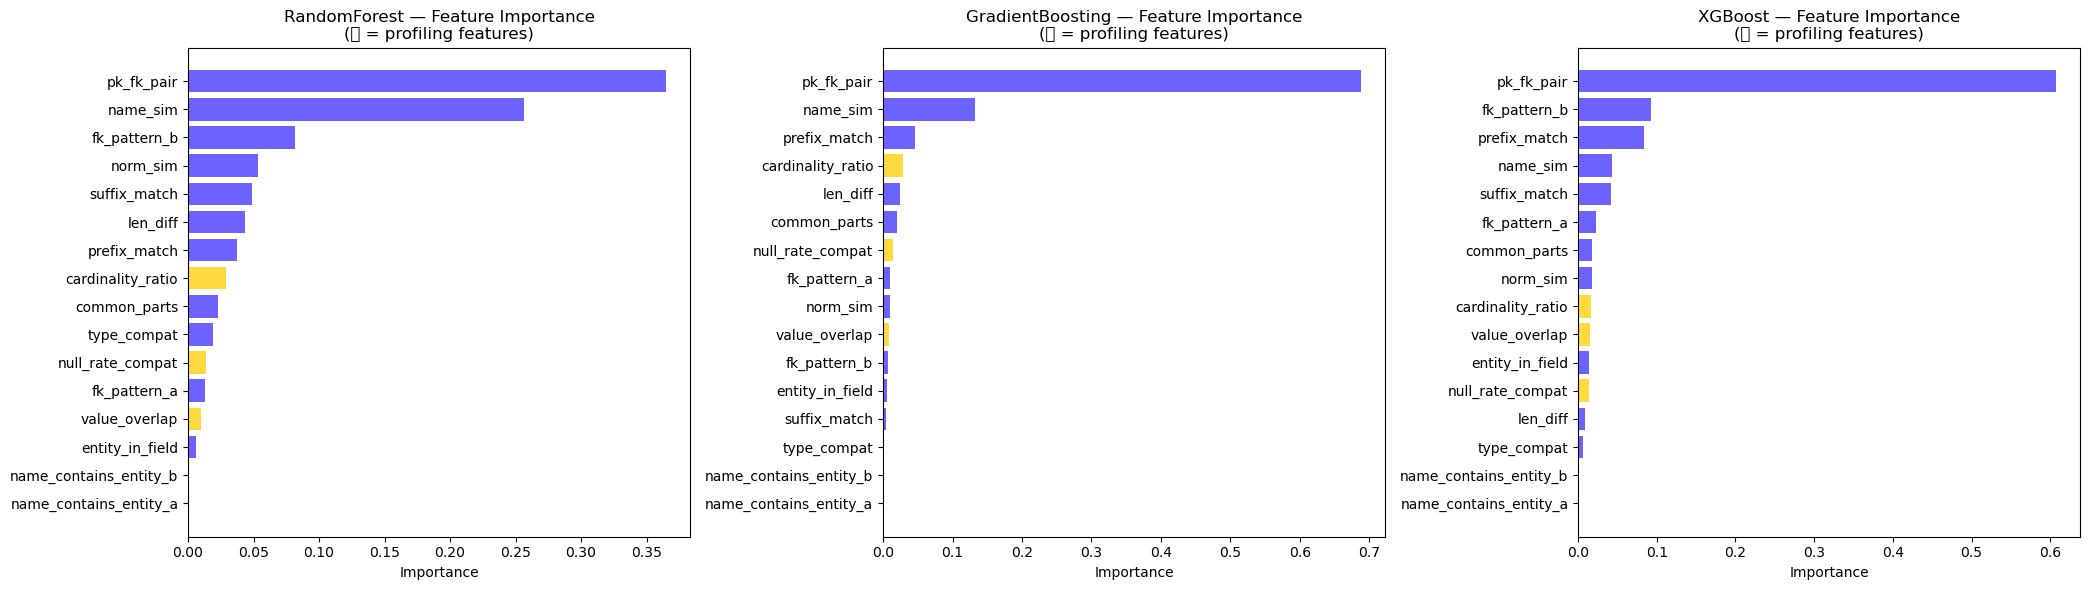

✅ Sauvegardé : ml_feature_importance.png


In [14]:
fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 6))
if len(models) == 1: axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    if not hasattr(model, 'feature_importances_'):
        ax.set_title(f'{name} — pas de feature_importances_')
        continue
    imp = model.feature_importances_
    idx = np.argsort(imp)
    colors = ['#ffd93d' if FEATURE_COLS[i] in ['value_overlap','cardinality_ratio','null_rate_compat']
              else '#6c63ff' for i in idx]
    ax.barh([FEATURE_COLS[i] for i in idx], imp[idx], color=colors)
    ax.set_title(f'{name} — Feature Importance\n(🟡 = profiling features)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : ml_feature_importance.png')

## 10b. 📊 Rapport complet par modèle (ROC, PR, Confusion Matrix)

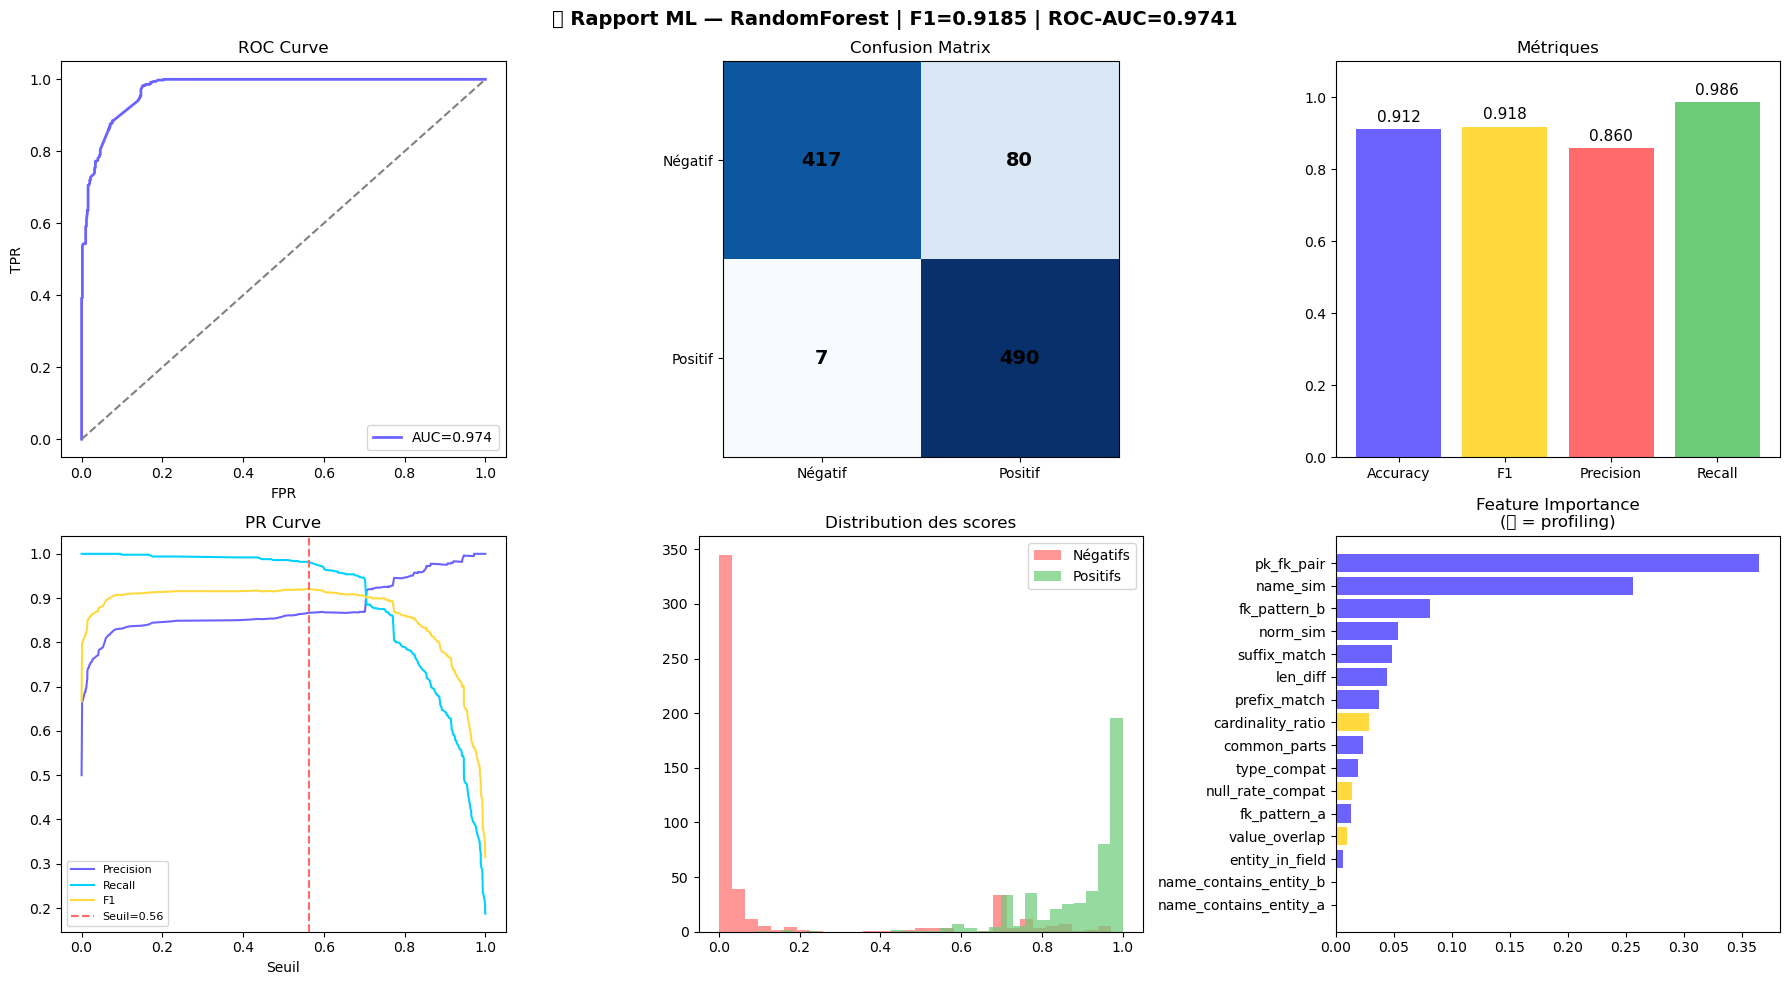

✅ Rapport RandomForest sauvegardé


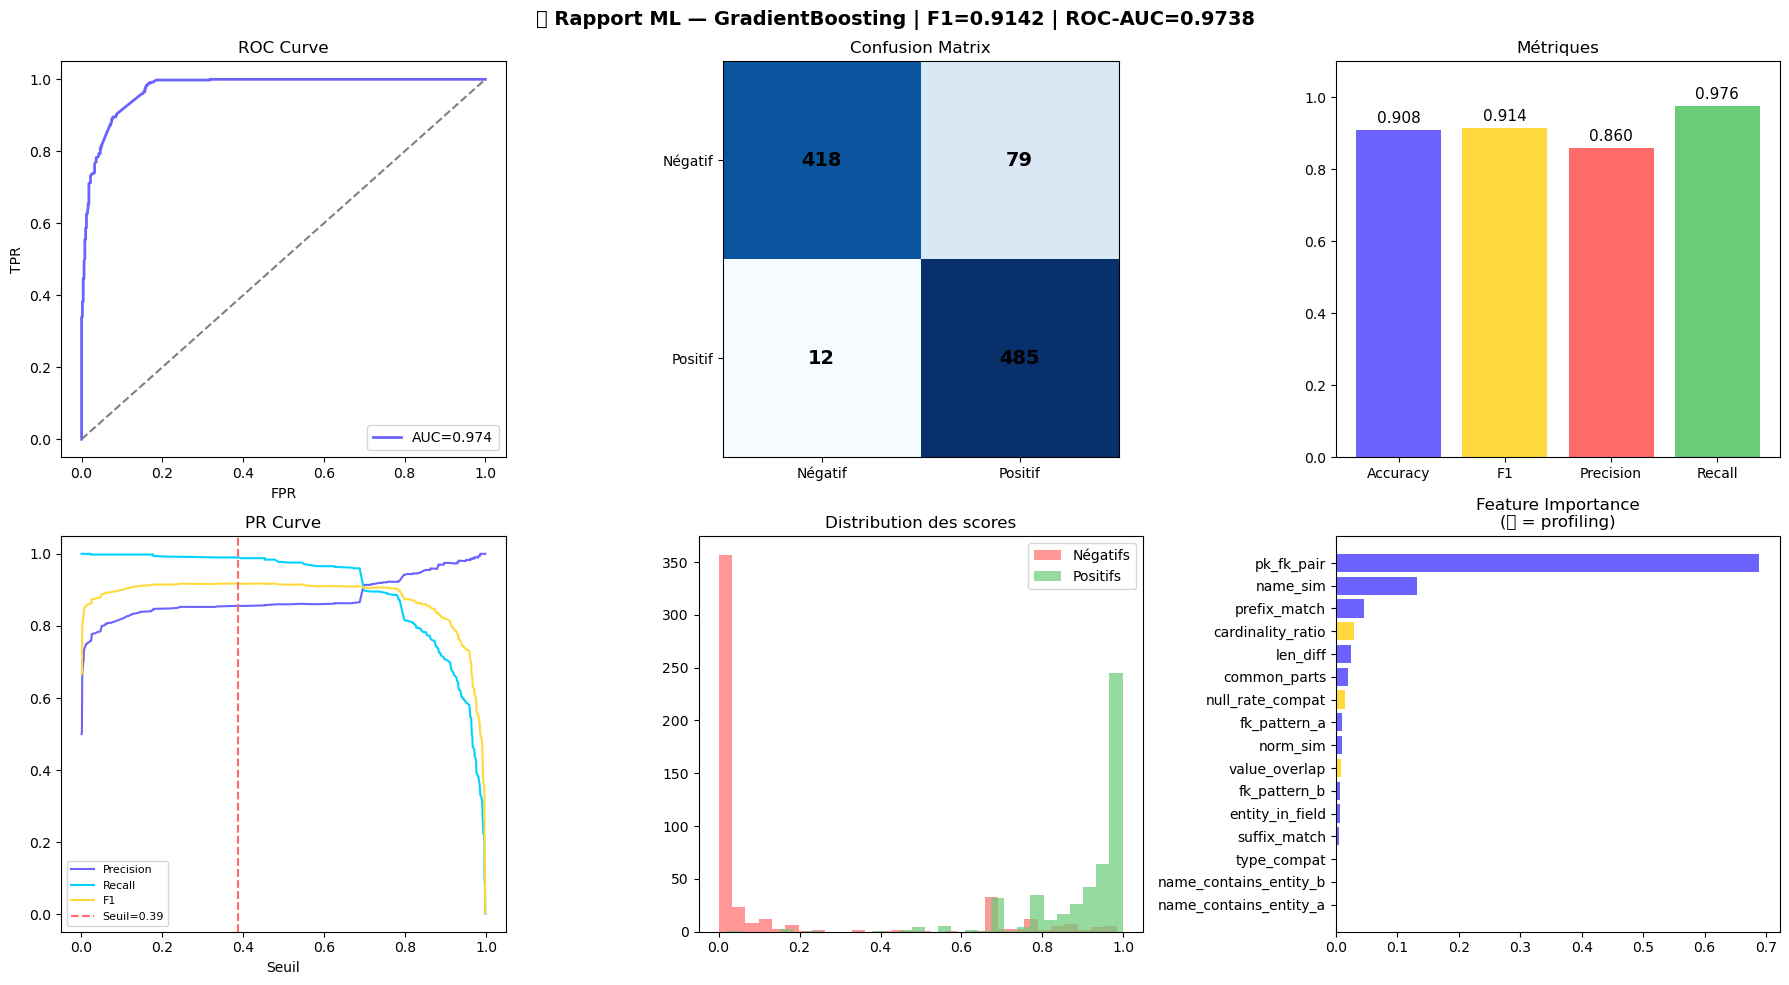

✅ Rapport GradientBoosting sauvegardé


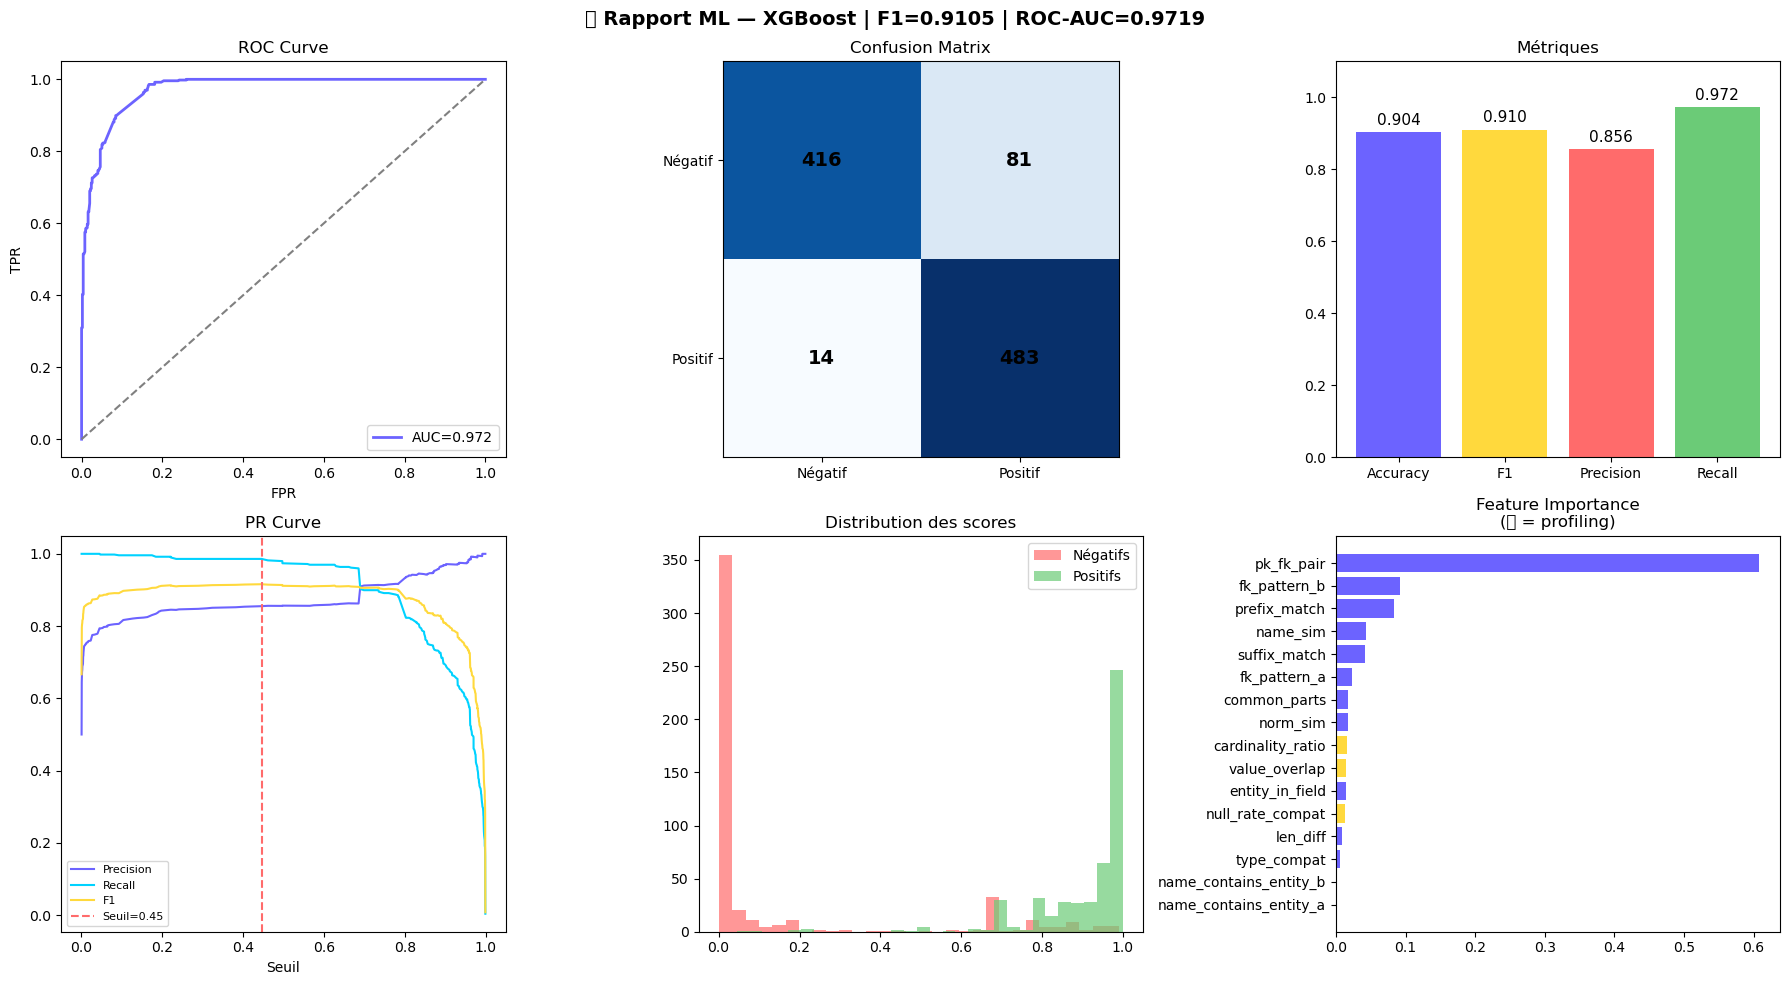

✅ Rapport XGBoost sauvegardé


In [15]:
for name, r in results.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'🤖 Rapport ML — {name} | F1={r["f1"]:.4f} | ROC-AUC={r["roc_auc"]:.4f}',
                 fontsize=14, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0,0].plot(fpr, tpr, color='#6c63ff', lw=2, label=f'AUC={r["roc_auc"]:.3f}')
    axes[0,0].plot([0,1],[0,1],'--',color='gray'); axes[0,0].set_title('ROC Curve')
    axes[0,0].legend(); axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')

    cm = r['cm']
    axes[0,1].imshow(cm, cmap='Blues')
    axes[0,1].set_title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            axes[0,1].text(j, i, cm[i,j], ha='center', va='center', fontsize=14, fontweight='bold')
    axes[0,1].set_xticks([0,1]); axes[0,1].set_yticks([0,1])
    axes[0,1].set_xticklabels(['Négatif','Positif']); axes[0,1].set_yticklabels(['Négatif','Positif'])

    metrics = {'Accuracy': r['acc'], 'F1': r['f1'], 'Precision': r['prec'], 'Recall': r['rec']}
    bars = axes[0,2].bar(metrics.keys(), metrics.values(), color=['#6c63ff','#ffd93d','#ff6b6b','#6bcb77'])
    axes[0,2].set_ylim(0, 1.1); axes[0,2].set_title('Métriques')
    for bar, v in zip(bars, metrics.values()):
        axes[0,2].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=11)

    prec_c, rec_c, thr_c = precision_recall_curve(y_test, r['y_proba'])
    f1_c = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-9)
    axes[1,0].plot(thr_c, prec_c[:-1], color='#6c63ff', label='Precision')
    axes[1,0].plot(thr_c, rec_c[:-1],  color='#00d2ff', label='Recall')
    axes[1,0].plot(thr_c, f1_c,         color='#ffd93d', label='F1')
    axes[1,0].axvline(thr_c[np.argmax(f1_c)], color='#ff6b6b', linestyle='--',
                      label=f'Seuil={thr_c[np.argmax(f1_c)]:.2f}')
    axes[1,0].set_title('PR Curve'); axes[1,0].legend(fontsize=8); axes[1,0].set_xlabel('Seuil')

    axes[1,1].hist(r['y_proba'][y_test==0], bins=30, alpha=0.7, color='#ff6b6b', label='Négatifs')
    axes[1,1].hist(r['y_proba'][y_test==1], bins=30, alpha=0.7, color='#6bcb77', label='Positifs')
    axes[1,1].set_title('Distribution des scores'); axes[1,1].legend()

    if hasattr(r['model'], 'feature_importances_'):
        imp = r['model'].feature_importances_
        idx = np.argsort(imp)
        colors_fi = ['#ffd93d' if FEATURE_COLS[i] in ['value_overlap','cardinality_ratio','null_rate_compat']
                     else '#6c63ff' for i in idx]
        axes[1,2].barh([FEATURE_COLS[i] for i in idx], imp[idx], color=colors_fi)
        axes[1,2].set_title('Feature Importance\n(🟡 = profiling)')

    plt.tight_layout()
    plt.savefig(f'ml_report_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Rapport {name} sauvegardé')

## 11. 🔄 Cross-Validation 5-fold

In [16]:
print(f'🔄 Cross-Validation 5-fold sur {BEST_MODEL_NAME}...\n')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for metric, scoring in [('Accuracy','accuracy'), ('F1','f1')]:
    scores = cross_val_score(BEST_MODEL, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'  {metric:10s} : {scores.mean():.4f} ± {scores.std():.4f}  '
          f'(min={scores.min():.4f} max={scores.max():.4f})')
print('\n✅ Cross-validation terminée')

🔄 Cross-Validation 5-fold sur RandomForest...

  Accuracy   : 0.9062 ± 0.0039  (min=0.9004 max=0.9114)
  F1         : 0.9132 ± 0.0034  (min=0.9086 max=0.9184)

✅ Cross-validation terminée


## 12. 🎯 Prédiction sur Paires Inconnues
**v7 :** stratification FK par table + garde-fou mémoire + MAX_RESULTS=None

📊 Seuil optimal (max F1) : 0.562
   Precision=0.867 | Recall=0.982 | F1=0.921


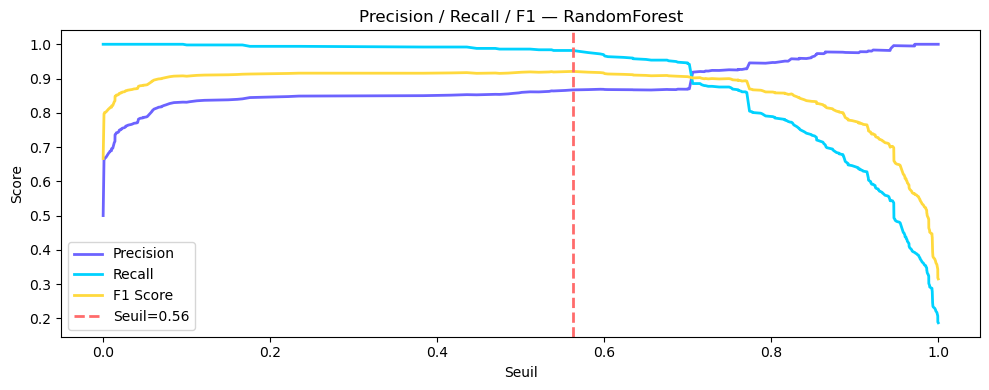


🔗 FK candidates : 3,793 (1239 tables couvertes)
🔑 PK candidates : 600
📐 Paires estimées : 2,275,800
⚠️  Sous-échantillonnage → 50,000 paires retenues (seed=42, reproductible)
⏳ Calcul des features sur 50,000 paires...
✅ 50,000 paires calculées

🎯 2,637 relations prédites (seuil=0.562)
   Confidence moyenne : 0.898
   Confidence max     : 0.999
   Confidence min     : 0.562


,source_entity,source_field,target_entity,target_field,confidence
889,DI_BLSN,CUR_ID_REPORTCCY,CS_CPW_FLTR_2_CUR,CUR_ID,0.999463
1524,DI_TRSR,CUR_ID_REPORTCCY,CS_CPW_FLTR_2_CUR,CUR_ID,0.999463
1490,DI_TRNB,CUR_ID_PRPTRNCCY,CS_RPT_BA_F_2_CCY,CUR_ID,0.999463
571,CS_DSCRLIMIT,CUR_ID_CURRENCY,CS_RPT_BA_F_2_CCY,CUR_ID,0.997875
1288,DI_SL,SL_ID,CS_RUL_PRM_A,RUL_PRM_ID,0.996377
1701,GS_BNK_ADDR,BNK_ADDR_ID,CS_CPW_FLTR_2_CMP,CMP_ID,0.995446
468,CS_CPW_FLTR_2_CMP,CMP_ID,AA_LTUSRTLD,LTUSRTLD_ID,0.995446
215,CS_AVCDTN,CMP_ID,CS_FLOWSCTS,FLOWSCTS_ID,0.995446
1496,DI_TRNB,PRTFL_ID_PRTFL,CS_CSHFL_U,UDFDEF_ID,0.994971
1996,PY_PAYTM,ACC_IDNT_ID_FACID,CS_CPW_CODE_A,CPW_CODE_ID,0.994572


In [17]:
# ── Seuil optimal via PR curve ──
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(
    y_test, results[BEST_MODEL_NAME]['y_proba']
)
f1_pr    = 2*(precisions_pr[:-1]*recalls_pr[:-1])/(precisions_pr[:-1]+recalls_pr[:-1]+1e-9)
best_idx = np.argmax(f1_pr)
THRESHOLD = float(thresholds_pr[best_idx])

print(f'📊 Seuil optimal (max F1) : {THRESHOLD:.3f}')
print(f'   Precision={precisions_pr[best_idx]:.3f} | Recall={recalls_pr[best_idx]:.3f} | F1={f1_pr[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds_pr, precisions_pr[:-1], color='#6c63ff', label='Precision', lw=2)
ax.plot(thresholds_pr, recalls_pr[:-1],    color='#00d2ff', label='Recall',    lw=2)
ax.plot(thresholds_pr, f1_pr,              color='#ffd93d', label='F1 Score',  lw=2)
ax.axvline(THRESHOLD, color='#ff6b6b', linestyle='--', lw=2, label=f'Seuil={THRESHOLD:.2f}')
ax.set_xlabel('Seuil'); ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 — {BEST_MODEL_NAME}')
ax.legend(); plt.tight_layout(); plt.show()

# ── v7 : Stratification FK par table ──
# Au lieu de prendre toutes les FK sans cap (risque explosion),
# on prend FK_PER_TABLE colonnes par table → couverture uniforme
fk_by_table = defaultdict(list)
for _, r in df_fields.iterrows():
    if r['is_foreign_key'] or fk_pat(r['field_name']) > 0:
        fk_by_table[r['entity_name']].append(r)

fk_cands = []
for table, cols in fk_by_table.items():
    expl = [c for c in cols if c['is_foreign_key']]
    impl = [c for c in cols if not c['is_foreign_key']]
    selected = expl[:FK_PER_TABLE]
    rem = FK_PER_TABLE - len(selected)
    if rem > 0: selected += impl[:rem]
    fk_cands += selected

pk_cands = list(df_fields[df_fields['is_primary_key'] == True].iterrows())[:PK_CAP]

print(f'\n🔗 FK candidates : {len(fk_cands):,} ({len(fk_by_table)} tables couvertes)')
print(f'🔑 PK candidates : {len(pk_cands):,}')
n_pairs_est = len(fk_cands) * len(pk_cands)
print(f'📐 Paires estimées : {n_pairs_est:,}')

# ── Génération des paires ──
all_pairs_meta = []
for fa in fk_cands:
    for fb_row in pk_cands:
        _, fb = fb_row
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'], fb['entity_name']) in positive_set: continue
        all_pairs_meta.append((fa, fb))

# ── Garde-fou mémoire : sous-échantillonnage si > PAIRS_MAX ──
if len(all_pairs_meta) > PAIRS_MAX:
    random.seed(42)
    all_pairs_meta = random.sample(all_pairs_meta, PAIRS_MAX)
    print(f'⚠️  Sous-échantillonnage → {PAIRS_MAX:,} paires retenues (seed=42, reproductible)')

print(f'⏳ Calcul des features sur {len(all_pairs_meta):,} paires...')

unknown_pairs = []
for fa, fb in all_pairs_meta:
    feat = compute_features(
        fa['entity_name'], fa['field_name'], fa['data_type'], fa['is_primary_key'], fa['is_foreign_key'],
        fb['entity_name'], fb['field_name'], fb['data_type'], fb['is_primary_key'], fb['is_foreign_key']
    )
    feat.update({
        'source_entity': fa['entity_name'], 'source_field': fa['field_name'],
        'target_entity': fb['entity_name'], 'target_field': fb['field_name'],
    })
    unknown_pairs.append(feat)

df_unknown = pd.DataFrame(unknown_pairs)
print(f'✅ {len(df_unknown):,} paires calculées')

proba = BEST_MODEL.predict_proba(df_unknown[FEATURE_COLS].values)[:, 1]
df_unknown['confidence'] = proba

# ── Filtrage + déduplication ──
df_preds = (
    df_unknown[df_unknown['confidence'] >= THRESHOLD]
    .sort_values('confidence', ascending=False)
    .groupby(['source_entity','source_field'])
    .first()
    .reset_index()
    .sort_values('confidence', ascending=False)
    .pipe(lambda df: df.head(MAX_RESULTS) if MAX_RESULTS else df)   # v7 : conditionnel
)

print(f'\n🎯 {len(df_preds):,} relations prédites (seuil={THRESHOLD:.3f})')
print(f'   Confidence moyenne : {df_preds["confidence"].mean():.3f}')
print(f'   Confidence max     : {df_preds["confidence"].max():.3f}')
print(f'   Confidence min     : {df_preds["confidence"].min():.3f}')
display(df_preds[['source_entity','source_field','target_entity','target_field','confidence']].head(25))

## 13. 📊 Visualisation des Prédictions

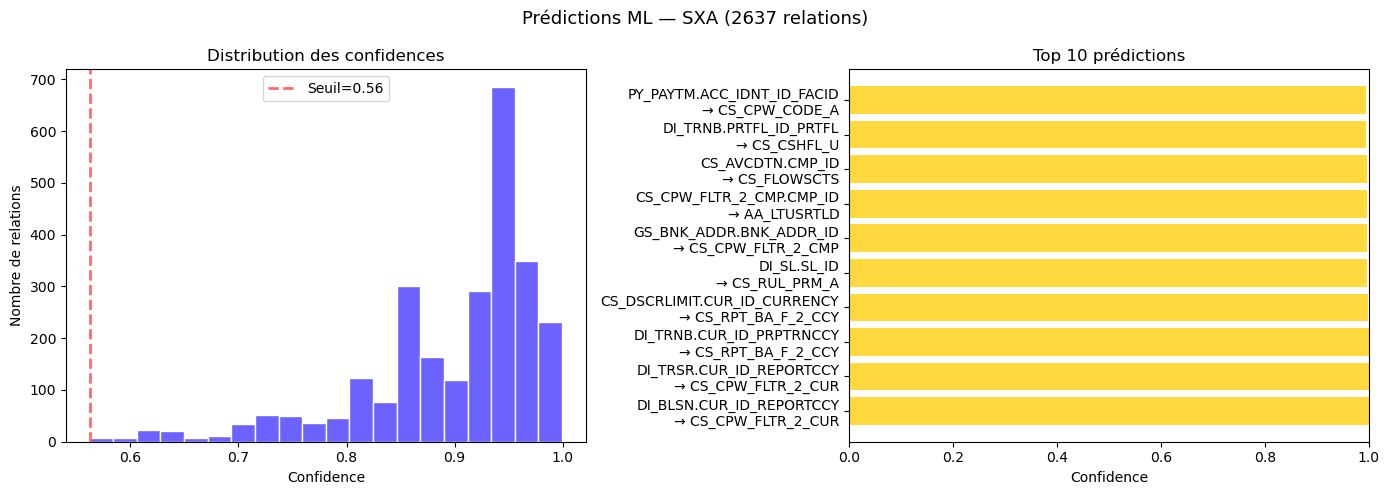

✅ Sauvegardé : ml_predictions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Prédictions ML — {SOURCE_NAME} ({len(df_preds)} relations)', fontsize=13)

axes[0].hist(df_preds['confidence'], bins=20, color='#6c63ff', edgecolor='white')
axes[0].axvline(THRESHOLD, color='#ff6b6b', linestyle='--', lw=2, label=f'Seuil={THRESHOLD:.2f}')
axes[0].set_title('Distribution des confidences')
axes[0].legend(); axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Nombre de relations')

top10  = df_preds.head(10)
labels = [f'{r.source_entity}.{r.source_field}\n→ {r.target_entity}' for _, r in top10.iterrows()]
axes[1].barh(labels, top10['confidence'], color='#ffd93d')
axes[1].set_xlim(0, 1); axes[1].set_title('Top 10 prédictions')
axes[1].set_xlabel('Confidence')

plt.tight_layout()
plt.savefig('ml_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : ml_predictions.png')

## 14. 💾 Sauvegarde en Base de Données
**v7 :** ON CONFLICT DO UPDATE (plus robuste que delete+insert)

In [19]:
conn = await get_conn()

# Supprimer les anciennes prédictions ML pour cette source
deleted = await conn.execute("""
    DELETE FROM entity_relations
    WHERE source_id = $1
      AND detection_method = 'ml_predicted'
""", SOURCE_ID)
print(f'🗑️  Anciennes prédictions supprimées : {deleted}')
print(f'📊 Prédictions à insérer : {len(df_preds)}')

inserted = errors = 0
for _, row in df_preds.iterrows():
    try:
        await conn.execute("""
            INSERT INTO entity_relations
                (source_id, source_entity, source_field,
                 target_entity, target_field,
                 detection_method, confidence)
            VALUES ($1, $2, $3, $4, $5, 'ml_predicted', $6)
            ON CONFLICT (source_id, source_entity, source_field, target_entity)
            DO UPDATE SET
                confidence       = EXCLUDED.confidence,
                detection_method = EXCLUDED.detection_method
        """,
            SOURCE_ID,
            row['source_entity'], row['source_field'],
            row['target_entity'], row['target_field'],
            float(row['confidence'])
        )
        inserted += 1
    except Exception as e:
        errors += 1
        print(f'  ⚠️  {row["source_entity"]}.{row["source_field"]} → {row["target_entity"]}: {e}')

await conn.close()
print(f'\n✅ {inserted} insérées | ❌ {errors} erreurs')

🗑️  Anciennes prédictions supprimées : DELETE 0
📊 Prédictions à insérer : 2637

✅ 2637 insérées | ❌ 0 erreurs


## 15. 💿 Sauvegarde du Modèle (.pkl) + Résumé final

In [20]:
# ── v7 : pkl enrichi compatible ml_detector.py ──
model_path = f'best_model_{BEST_MODEL_NAME.lower()}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'model':        BEST_MODEL,
        'model_name':   BEST_MODEL_NAME,          # v7 : ajouté
        'feature_cols': FEATURE_COLS,
        'source_id':    str(SOURCE_ID),
        'threshold':    THRESHOLD,
        'trained_at':   datetime.utcnow().isoformat(),  # v7 : ajouté
        'metrics': {                                     # v7 : ajouté
            'f1':        results[BEST_MODEL_NAME]['f1'],
            'roc_auc':   results[BEST_MODEL_NAME]['roc_auc'],
            'precision': results[BEST_MODEL_NAME]['prec'],
            'recall':    results[BEST_MODEL_NAME]['rec'],
        },
    }, f)
print(f'✅ Modèle sauvegardé : {model_path}')

# ── Résumé DB ──
conn = await get_conn()
summary = await conn.fetch("""
    SELECT detection_method,
           COUNT(*) AS total,
           ROUND(AVG(confidence)::numeric, 3) AS avg_conf
    FROM entity_relations
    WHERE source_id = $1
    GROUP BY detection_method
    ORDER BY total DESC
""", SOURCE_ID)
await conn.close()

print('\n📋 Résumé complet des relations en DB :')
display(pd.DataFrame([dict(r) for r in summary]))

r = results[BEST_MODEL_NAME]
print(f'\n🎉 Pipeline ML v7 terminé !')
print(f'   Modèle     : {BEST_MODEL_NAME}')
print(f'   Features   : {len(FEATURE_COLS)} (13 noms/types + 3 profiling)')
print(f'   F1 Score   : {r["f1"]:.4f}')
print(f'   ROC-AUC    : {r["roc_auc"]:.4f}')
print(f'   Precision  : {r["prec"]:.4f}')
print(f'   Recall     : {r["rec"]:.4f}')
print(f'   Seuil      : {THRESHOLD:.3f} (auto via PR curve)')
print(f'   Insérées   : {inserted}')
print(f'   MAX_RESULTS: {MAX_RESULTS} (None = toutes)')
print(f'   → Voir dans OnePilot UI : http://localhost:3000')

✅ Modèle sauvegardé : best_model_randomforest.pkl

📋 Résumé complet des relations en DB :


,detection_method,total,avg_conf
0,ml_predicted,2637,0.898
1,explicit_fk,2483,1.000
2,heuristic_name_pascal,659,0.831
3,heuristic_value_based,159,0.814
4,heuristic_name_m2m,10,0.894
5,heuristic_fuzzy_match,10,0.668



🎉 Pipeline ML v7 terminé !
   Modèle     : RandomForest
   Features   : 16 (13 noms/types + 3 profiling)
   F1 Score   : 0.9185
   ROC-AUC    : 0.9741
   Precision  : 0.8596
   Recall     : 0.9859
   Seuil      : 0.562 (auto via PR curve)
   Insérées   : 2637
   MAX_RESULTS: None (None = toutes)
   → Voir dans OnePilot UI : http://localhost:3000


In [22]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "aiohttp", "-q"])
print("✅ aiohttp installé")

✅ aiohttp installé


In [24]:
import asyncpg
import aiohttp
import asyncio

DB_CONFIG = {
    'host': 'onepilot_postgres', 'port': 5432,
    'database': 'onepilot_dev', 'user': 'onepilot', 'password': 'onepilot_secret'
}
SOURCE_ID = '85a0ef4b-d9af-494f-b24f-ff710c21ba43'
API_BASE  = 'http://onepilot_api:8000'

# ── Changer ce seuil selon l'étape ──
SEUIL = 0.70   # étape 1 : confirme 70-100%
# SEUIL = 0.56 # étape 2 : confirme le reste

async def bulk_validate():
    conn = await asyncpg.connect(**DB_CONFIG)

    rows = await conn.fetch("""
        SELECT id, detection_method, confidence
        FROM entity_relations
        WHERE source_id = $1
          AND (is_confirmed IS NULL OR (is_confirmed = FALSE AND reject_reason IS NULL))
          AND confidence >= $2
        ORDER BY confidence DESC
    """, SOURCE_ID, SEUIL)

    await conn.close()

    if not rows:
        print(f"✅ Aucune relation en attente au-dessus de {SEUIL*100:.0f}%")
        return

    print(f"📊 {len(rows)} relations à confirmer (confidence >= {SEUIL*100:.0f}%)")
    print(f"   Confiance min : {min(r['confidence'] for r in rows)*100:.1f}%")
    print(f"   Confiance max : {max(r['confidence'] for r in rows)*100:.1f}%")

    validations = [{"id": r['id'], "is_confirmed": True} for r in rows]

    CHUNK = 500
    total = 0
    async with aiohttp.ClientSession() as session:
        for i in range(0, len(validations), CHUNK):
            chunk = validations[i:i+CHUNK]
            payload = {"validated_by": "admin", "validations": chunk}
            async with session.patch(
                f"{API_BASE}/sources/{SOURCE_ID}/relations/validate-bulk",
                json=payload
            ) as resp:
                result = await resp.json()
                total += result.get('validated', 0)
                print(f"  ✅ Chunk {i//CHUNK+1} : {result.get('validated', 0)} confirmées")

    print(f"\n🎉 Total confirmé : {total} relations")

await bulk_validate()

📊 2835 relations à confirmer (confidence >= 70%)
   Confiance min : 70.0%
   Confiance max : 99.8%
  ✅ Chunk 1 : 500 confirmées
  ✅ Chunk 2 : 500 confirmées
  ✅ Chunk 3 : 500 confirmées
  ✅ Chunk 4 : 500 confirmées
  ✅ Chunk 5 : 500 confirmées
  ✅ Chunk 6 : 335 confirmées

🎉 Total confirmé : 2835 relations
